In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import seaborn as sns
import yaml
from pathlib import Path

# Load the data

In [289]:
# select the experiments for which you want to analyse data
experiment_ids = [
    # "smith1_flash_t1_20260228_173738",
    # "smith1_pro_t1_20260228_150742",
    "smith1_t1_openai_20260324_232624",
    "smith1_t1_openai_personas_diverse_20260326_123803",
    # "smith2_flash_t1_20260228_173739",
    # "smith2_pro_t1_20260228_150742",
    # "smith3_flash_t1_20260228_173738",
    # "smith3_pro_t1_20260228_150742",
    # "smith4a_flash_t1_20260228_173738",
    # "smith4a_pro_t1_20260228_150742",
    # "smith6a_flash_t1_20260228_173739",
    # "smith6a_pro_t1_20260228_150742",
]

In [290]:
# set the paths
root_path = Path(globals()['_dh'][0]).parent

all_iteration_data = []
all_agent_data = []
configs = {}
for experiment_id in experiment_ids:

    results_path = root_path / 'results' / experiment_id
    
    # read the number of simulations from the config file
    with open(results_path / 'config_used.yaml', "r") as f:
        config = yaml.safe_load(f)
    n_sims = config['experiment']['n_simulations']

    # collect only simulations where both files exist
    available_sims = [
        sim for sim in range(1, n_sims + 1)
        if (results_path / 'data' / f'iteration_history_{sim}.csv').exists()
        and (results_path / 'data' / f'agent_histories_{sim}.csv').exists()
    ]

    # read the results data for all available simulations
    iteration_histories = [pd.read_csv(results_path / 'data' / f'iteration_history_{sim}.csv')
                        for sim in available_sims]

    agents_histories = [pd.read_csv(results_path / 'data' / f'agent_histories_{sim}.csv')
                        for sim in available_sims]

    # combine multiple simulations into a single dataframe
    df_data = pd.concat(
        [df.assign(sim=sim) for df, sim in zip(iteration_histories, available_sims)],
        ignore_index=True
    )
    df_data_agents = pd.concat(
        [df.assign(sim=sim) for df, sim in zip(agents_histories, available_sims)],
        ignore_index=True
    )

    # add experiment identifier
    df_data['experiment_id'] = experiment_id
    df_data_agents['experiment_id'] = experiment_id

    # append to the list
    all_iteration_data.append(df_data)
    all_agent_data.append(df_data_agents)

    # store experiment configs
    configs[experiment_id] = config.copy()

# combine all experiments into single dataframes
df_data_all = pd.concat(all_iteration_data, ignore_index=True)
df_data_agents_all = pd.concat(all_agent_data, ignore_index=True)

# Color palette for experiments
exp_colors = dict(zip(experiment_ids, ['#1565C0', '#E65100', '#2E7D32', '#6A1B9A', '#C62828']))

# Short labels for plotting (extract model name from experiment_id)
# exp_labels = {eid: eid.split('_')[0] + '_' + eid.split('_')[1] for eid in experiment_ids}
# Or override manually:
# exp_labels = {experiment_ids[0]: 'Flash', experiment_ids[1]: 'Pro'}
# Or use full names
exp_labels = {eid: eid for eid in experiment_ids}

print(f"Combined iteration data shape: {df_data_all.shape}")
print(f"Combined agent data shape: {df_data_agents_all.shape}")
print(f"Experiments: {df_data_all['experiment_id'].unique()}")
print(f"Simulations per experiment: \n{df_data_all.groupby('experiment_id')['sim'].nunique()}")

Combined iteration data shape: (5638, 14)
Combined agent data shape: (7037, 11)
Experiments: ['smith1_t1_openai_20260324_232624'
 'smith1_t1_openai_personas_diverse_20260326_123803']
Simulations per experiment: 
experiment_id
smith1_t1_openai_20260324_232624                     5
smith1_t1_openai_personas_diverse_20260326_123803    5
Name: sim, dtype: int64


# Calculate the Equilibrium Price/Quantity for each experiment

In [291]:
def find_equilibrium(supply, demand, flat_threshold=1e-10):
    """
    Find equilibrium quantity and price where demand >= supply.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        flat_threshold: tolerance for considering a curve "flat"
    
    Returns:
        q_eq: equilibrium quantity (number of trades)
        p_eq: equilibrium price
        p_supply: supply price at last trade
        p_demand: demand price at last trade
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    n = min(len(supply), len(demand))
    
    # Find last index where demand >= supply
    viable_mask = demand[:n] >= supply[:n]
    
    if not viable_mask.any():
        return 0, None, None, None
    
    last_idx = np.flatnonzero(viable_mask)[-1]
    next_idx = last_idx + 1
    
    q_eq = last_idx + 1
    p_supply = supply[last_idx]
    p_demand = demand[last_idx]
    
    # Check what happens at the next quantity unit
    has_next_supply = next_idx < len(supply)
    has_next_demand = next_idx < len(demand)
    
    # Determine price based on curve behavior at equilibrium
    if not has_next_supply:
        # Supply is vertical (ran out) - price based on demand side
        p_eq = (p_demand + demand[next_idx]) / 2 if has_next_demand else p_demand
    elif not has_next_demand:
        # Demand is vertical (ran out) - price based on supply side
        p_eq = (p_supply + supply[next_idx]) / 2 if has_next_supply else p_supply
    elif abs(supply[next_idx] - p_supply) < flat_threshold:
        # Supply is flat (perfectly elastic) - use supply price
        p_eq = p_supply
    elif abs(demand[next_idx] - p_demand) < flat_threshold:
        # Demand is flat (perfectly elastic) - use demand price
        p_eq = p_demand
    else:
        # Both curves have slope - use midpoint
        p_eq = (p_supply + p_demand) / 2
    
    return q_eq, p_eq

In [292]:
equilibria = {}

# calculate theoretical equilibrium for each experiment
for experiment_id in experiment_ids:

    # generate the demand schedule
    demand = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["buyers"]["max"],
            configs[experiment_id]["experiment"]["buyers"]["min"],
            configs[experiment_id]["experiment"]["buyers"]["num"],
        ),
        2,
    )

    # generate the supply schedule
    supply = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["sellers"]["min"],
            configs[experiment_id]["experiment"]["sellers"]["max"],
            configs[experiment_id]["experiment"]["sellers"]["num"],
        ),
        2,
    )
    
    # calculate the equilibrium
    q_eq, p_eq = find_equilibrium(supply=supply, demand=demand)
    
    # store
    df_data_all.loc[df_data_all["experiment_id"]==experiment_id, "equilibrium_price"] = p_eq
    df_data_all.loc[df_data_all["experiment_id"]==experiment_id, "equilibrium_quantity"] = q_eq
    equilibria[experiment_id] = {"price": p_eq, "quantity": q_eq}

## Plot the Supply and Demand Curves

In [293]:
def plot_equilibrium(supply, demand, q_eq, p_eq, title=None, ax=None):
    """
    Visualize supply and demand curves with equilibrium point.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        q_eq: equilibrium quantity
        p_eq: equilibrium price
        title: optional plot title
        ax: optional matplotlib axes (creates new figure if None)
    
    Returns:
        matplotlib axes object
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    quantities_supply = np.arange(len(supply)) + 1
    quantities_demand = np.arange(len(demand)) + 1
    
    ax.step(quantities_supply, supply, 'b-', where='pre', label='Supply', linewidth=2)
    ax.step(quantities_demand, demand, 'r-', where='pre', label='Demand', linewidth=2)
    
    y_max = max(supply[-1], demand[0]) * 1.2
    
    # Extend supply vertically upward
    ax.vlines(len(supply), supply[-1], y_max, colors='blue', linewidth=2)
    
    # Extend demand vertically downward
    ax.vlines(len(demand), demand[-1], 0, colors='red', linewidth=2)
    
    if q_eq > 0 and p_eq is not None:
        ax.plot(q_eq, p_eq, 'go', markersize=12,
                label=f'Equilibrium: Q={q_eq}, P={p_eq:.2f}', zorder=5)
        ax.axhline(p_eq, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.axvline(q_eq, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(title or 'Supply and Demand - Equilibrium')
    ax.set_ylim(0, y_max)
    
    return ax

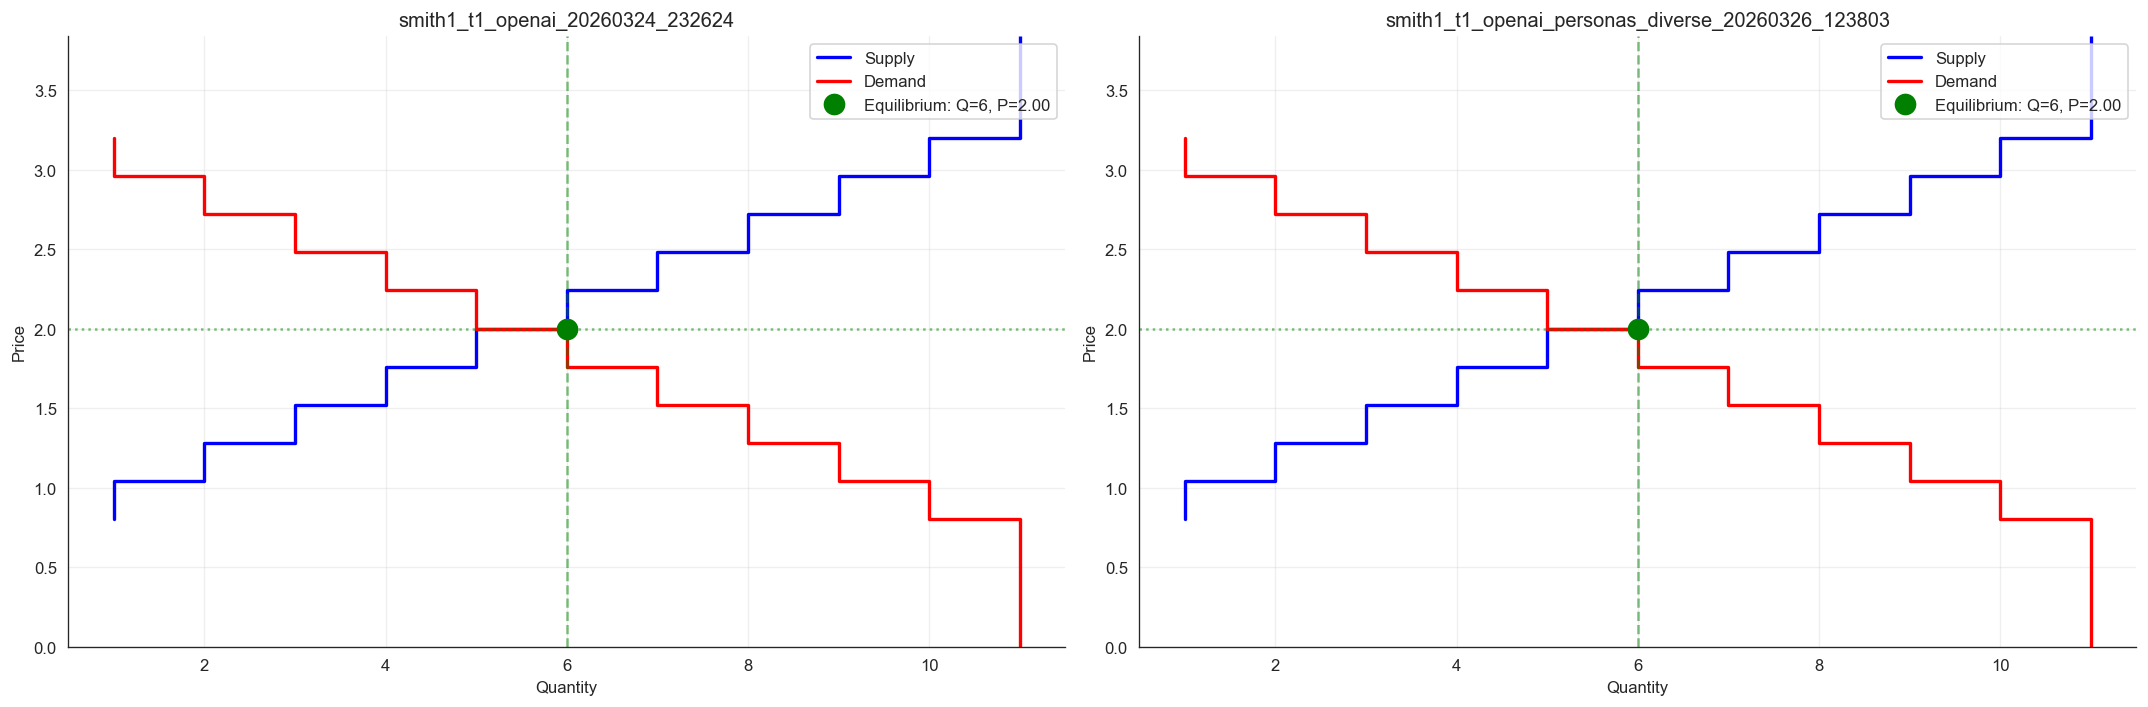

In [294]:
fig, axes = plt.subplots(1, len(experiment_ids), figsize=(9 * len(experiment_ids), 6))
supply_schedules = {}
demand_schedules = {}

# plot for each experiment
for experiment_id, ax in zip(experiment_ids, axes):

    # generate the demand schedule
    demand = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["buyers"]["max"],
            configs[experiment_id]["experiment"]["buyers"]["min"],
            configs[experiment_id]["experiment"]["buyers"]["num"],
        ),
        2,
    )
    demand_schedules[experiment_id] = demand

    # generate the supply schedule
    supply = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["sellers"]["min"],
            configs[experiment_id]["experiment"]["sellers"]["max"],
            configs[experiment_id]["experiment"]["sellers"]["num"],
        ),
        2,
    )
    supply_schedules[experiment_id] = supply

    # plot
    plot_equilibrium(supply, demand, equilibria[experiment_id]['quantity'], equilibria[experiment_id]['price'], title=experiment_id, ax=ax)


plt.tight_layout()
plt.show()

# Market-Wide Analysis

## Convergence to Theoretical Equilibrium

In [295]:
# Smith (1962) "An Experimental Study of Competitive Market Behavior"
# All values from Table 1
# Keys: experiment name -> {round_number: value}
 
# Coefficient of convergence: alpha = 100 * sigma_0 / P0
# where sigma_0 = std of exchange prices around equilibrium price (not around mean)
smith_alpha = {
    "smith1": {1: 11.8, 2: 8.1, 3: 5.2, 4: 5.5, 5: 3.5},
    "smith2": {1: 9.9, 2: 5.4, 3: 2.2},
    "smith3": {1: 16.5, 2: 6.6, 3: 3.7, 4: 5.7},
    "smith4a": {1: 19.1, 2: 10.4, 3: 7.8, 4: 7.6},
    "smith4b": {1: 6.9, 2: 7.1, 3: 6.5},
    "smith5a": {1: 2.0, 2: 0.7, 3: 0.7, 4: 0.6},
    "smith5b": {1: 9.4, 2: 4.3},
    "smith6a": {1: 53.8, 2: 38.7, 3: 21.1, 4: 9.4},
    "smith6b": {1: 11.0},
    "smith7": {1: 49.1, 2: 22.2, 3: 7.1, 4: 5.4, 5: 3.0, 6: 2.7},
    "smith8a": {1: 19.0, 2: 2.9, 3: 7.4, 4: 7.0},
    "smith8b": {1: 7.8, 2: 6.1},
    "smith9a": {1: 21.8, 2: 15.4, 3: 13.2},
    "smith9b": {1: 10.3},
    "smith10": {1: 11.0, 2: 3.2, 3: 2.2},
}

In [296]:
def calculate_coefficient_of_convergence(prices: np.ndarray, equilibrium_price: float):
    """Calculates the coefficient of convergene of prices to equilibrium (alpha) from the Smith (1962) paper.
    
    Parameters:
        prices: array of prices within a round
        equilibrium_price: theoretical equilibrium price    
    Returns:
        alpha: coefficient of convergene
    """
    squared_deviations = (prices - equilibrium_price)**2 
    var = squared_deviations.sum()/len(prices)
    std = var**0.5
    alpha = 100*std/equilibrium_price
    return alpha

df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()
coefficients_of_convergence = df_transactions_all.groupby(['experiment_id', 'sim', 'round'])['price'].agg(
    lambda prices: calculate_coefficient_of_convergence(prices.values, equilibrium_price=p_eq)
).reset_index(name='coefficient_of_convergence')
coefficients_of_convergence['smith'] = coefficients_of_convergence.apply(
    lambda row: smith_alpha[row['experiment_id'].split('_')[0]].get(row['round']), axis=1)

In [297]:
coefficients_of_convergence['smith'] = coefficients_of_convergence.apply(
    lambda row: smith_alpha[row['experiment_id'].split('_')[0]].get(row['round']), axis=1)
coefficients_of_convergence

,experiment_id,sim,round,coefficient_of_convergence,smith
0,smith1_t1_openai_20260324_232624,1,1,36.660606,11.8
1,smith1_t1_openai_20260324_232624,1,2,33.406586,8.1
2,smith1_t1_openai_20260324_232624,1,3,33.941125,5.2
3,smith1_t1_openai_20260324_232624,1,4,22.847319,5.5
4,smith1_t1_openai_20260324_232624,1,5,35.552778,3.5
5,smith1_t1_openai_20260324_232624,2,1,35.305807,11.8
6,smith1_t1_openai_20260324_232624,2,2,29.041842,8.1
7,smith1_t1_openai_20260324_232624,2,3,30.761757,5.2
8,smith1_t1_openai_20260324_232624,2,4,32.249031,5.5
9,smith1_t1_openai_20260324_232624,2,5,36.331804,3.5


### Multiple Simulations Convergence Overview

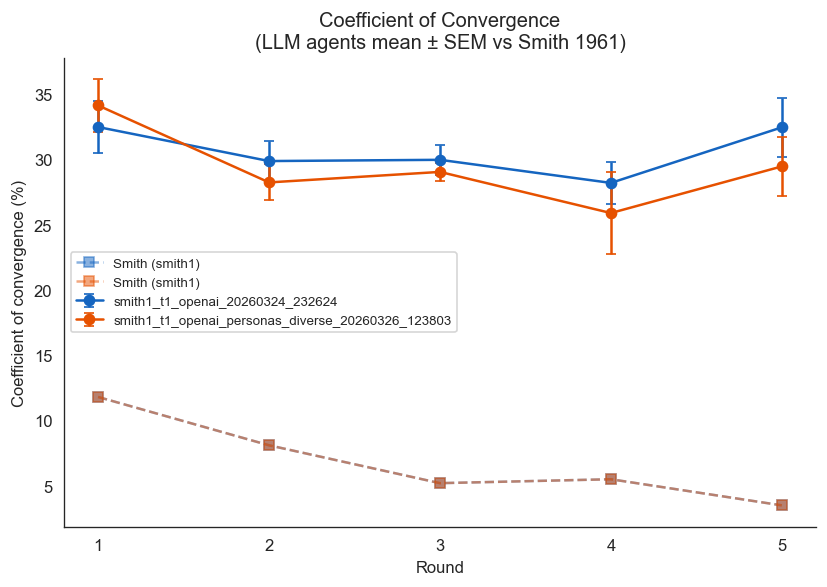

In [298]:
# ============================================================
# Coefficient of Convergence: LLM experiments vs Smith (1961)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

for eid in experiment_ids:
    color = exp_colors[eid]
    sub = coefficients_of_convergence[coefficients_of_convergence['experiment_id'] == eid]

    # LLM simulations (mean ± SEM across sims)
    sr = sub.groupby('round')['coefficient_of_convergence'].agg(['mean', 'sem'])
    ax.errorbar(sr.index, sr['mean'], yerr=sr['sem'],
                fmt='-o', color=color, capsize=3, markersize=6, label=exp_labels[eid])

    # Smith (1961) — one value per round
    smith_vals = sub.drop_duplicates('round')[['round', 'smith']].dropna().sort_values('round')
    if not smith_vals.empty:
        smith_key = eid.split('_')[0]
        ax.plot(smith_vals['round'], smith_vals['smith'],
                '--s', color=color, markersize=6, alpha=0.5, label=f'Smith ({smith_key})')

ax.set_xlabel('Round')
ax.set_ylabel('Coefficient of convergence (%)')
ax.set_title('Coefficient of Convergence\n(LLM agents mean ± SEM vs Smith 1961)')
ax.set_xticks(sorted(coefficients_of_convergence['round'].unique()))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

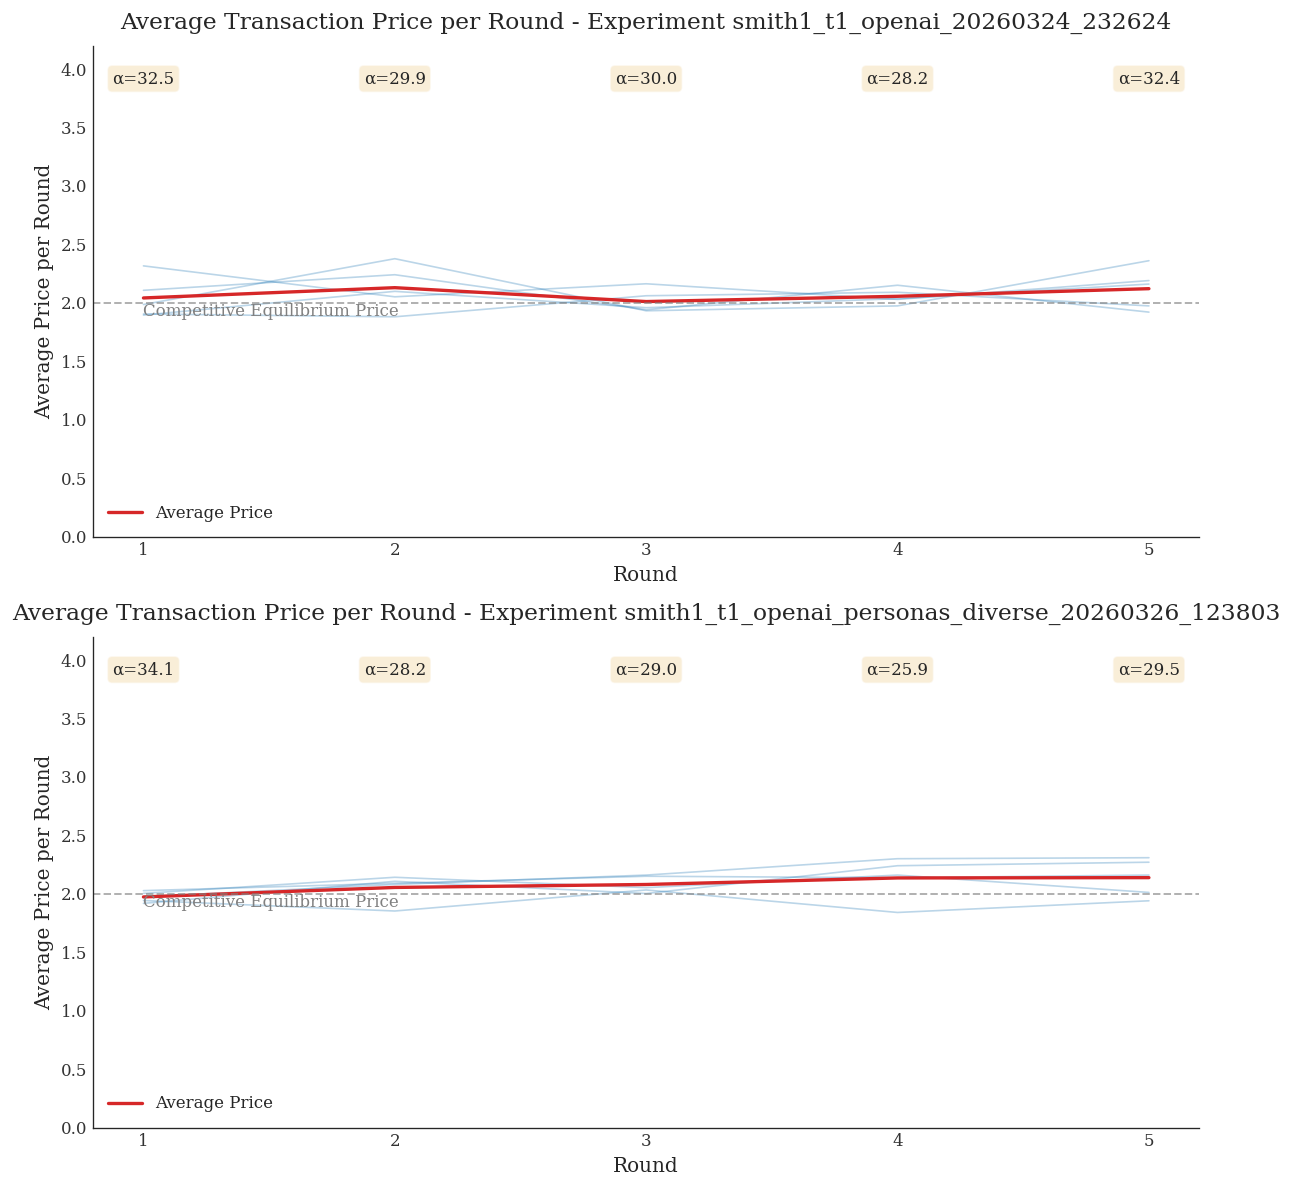

In [299]:
# Get unique experiments
experiments = df_data_all['experiment_id'].unique()
n_experiments = len(experiments)

# Create subplots - one row per experiment
fig, axes = plt.subplots(nrows=n_experiments, figsize=(10, 5 * n_experiments))

# Handle case where there's only one experiment (axes won't be an array)
if n_experiments == 1:
    axes = [axes]

sim_color = '#1f77b4'
avg_color = '#d62728'

for idx, experiment_id in enumerate(experiments):
    ax = axes[idx]
    
    # Filter data for this experiment
    df_data_exp = df_data_all[df_data_all['experiment_id'] == experiment_id]
    coefficients_exp = coefficients_of_convergence[
        coefficients_of_convergence['experiment_id'] == experiment_id
    ]
    
    df_transactions_exp = df_data_exp.loc[df_data_exp['transaction_made'] == True].reset_index()
    sim_round_avg = df_transactions_exp.groupby(['sim', 'round'])['price'].agg(['mean', 'std', 'count']).reset_index()
    df_plot = sim_round_avg.pivot_table(index='round', columns='sim', values='mean')
    
    # Compute average alpha per round across simulations for this experiment
    avg_alpha = (
        coefficients_exp
        .groupby('round')['coefficient_of_convergence']
        .mean()
    )
    
    # Dynamic axis limits
    y_min = np.max([np.concat([supply_schedules[experiment_id], demand_schedules[experiment_id]]).min() - 1, 0])
    y_max = np.concat([supply_schedules[experiment_id], demand_schedules[experiment_id]]).max() + 1
    y_range = y_max - y_min
    alpha_y_pos = y_max - 0.05 * y_range
    
    # Plot individual simulations
    for sim_id in df_plot.columns:
        ax.plot(df_plot.index, df_plot[sim_id], color=sim_color, alpha=0.3, linewidth=1)
    
    # Plot average price
    avg_prices = df_plot.mean(axis=1)
    ax.plot(df_plot.index, avg_prices, color=avg_color, linewidth=2, label='Average Price')
    
    # Equilibrium line
    ax.axhline(y=equilibria[experiment_id]["price"], color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.text(df_plot.index[0], equilibria[experiment_id]["price"] - 0.15, 'Competitive Equilibrium Price',
            color='grey', fontsize=10, family='serif', va='bottom')
    
    # Add average alpha annotation per round
    for round_num, alpha_value in avg_alpha.items():
        ax.text(round_num, alpha_y_pos, f'α={alpha_value:.1f}',
                ha='center', va='top', fontsize=10, family='serif',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Round', fontsize=12, family='serif')
    ax.set_ylabel('Average Price per Round', fontsize=12, family='serif')
    ax.set_title(f'Average Transaction Price per Round - Experiment {experiment_id}',
                 fontsize=14, family='serif', pad=10)
    
    ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_family('serif')
    ax.set_xticks(df_plot.index)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    ax.set_ylim(y_min, y_max)
    
    ax.legend(loc='lower left', frameon=False, prop={'family': 'serif', 'size': 10})
    ax.grid(False)

plt.tight_layout()
plt.show()

### Determine Submarginal Buyers/Sellers

In [300]:
# Initialize list to collect results from all experiments
all_market_summaries = []

for experiment_id in df_data_all['experiment_id'].unique():
    
    # Filter data for this experiment
    df_data_exp = df_data_all[df_data_all['experiment_id'] == experiment_id]
    df_transactions_exp = df_data_exp.loc[df_data_exp['transaction_made'] == True].reset_index()
    coefficients_exp = coefficients_of_convergence[
        coefficients_of_convergence['experiment_id'] == experiment_id
    ]
    
    # Get experiment-specific equilibrium values
    p_eq_exp = equilibria[experiment_id]["price"] 
    q_eq_exp = equilibria[experiment_id]["quantity"]
    supply_exp = supply_schedules[experiment_id]
    demand_exp = demand_schedules[experiment_id]
    
    # no. of submarginal sellers (reservation_price > theoretical equilibrium price)
    submarginal_sellers_number = (supply_exp > p_eq_exp).sum()
    
    # no. of submarginal buyers (reservation_price < theoretical equilibrium price)
    submarginal_buyers_number = (demand_exp < p_eq_exp).sum()
    
    # no. of submarginal sellers and buyers who made contracts
    df = df_transactions_exp.loc[df_transactions_exp["announcement_type"] == "sell"]
    result_sellers_announcers = df.groupby(['sim', 'round']).apply(
        lambda x: (x['announcing_agent_reservation_price'] > x['equilibrium_price']).sum(), include_groups=False)
    result_buyers_responders = df.groupby(['sim', 'round']).apply(
        lambda x: (x['responding_agent_reservation_price'] < x['equilibrium_price']).sum(), include_groups=False)
    
    df = df_transactions_exp.loc[df_transactions_exp["announcement_type"] == "buy"]
    result_buyers_announcers = df.groupby(['sim', 'round']).apply(
        lambda x: (x['announcing_agent_reservation_price'] < x['equilibrium_price']).sum(), include_groups=False)
    result_sellers_responders = df.groupby(['sim', 'round']).apply(
        lambda x: (x['responding_agent_reservation_price'] > x['equilibrium_price']).sum(), include_groups=False)
    
    combined_sellers = (result_sellers_announcers + result_sellers_responders).fillna(0).reset_index()
    combined_buyers = (result_buyers_announcers + result_buyers_responders).fillna(0).reset_index()
    
    # merge the buyers and sellers dfs
    combined_sellers = combined_sellers.rename(columns={0: "number of submarginal sellers who transacted"})
    combined_buyers = combined_buyers.rename(columns={0: "number of submarginal buyers who transacted"})
    submarginal_transactions_summary = combined_sellers.merge(combined_buyers, on=['sim', 'round'])
    submarginal_transactions_summary = submarginal_transactions_summary.astype(int)
    
    ### prepare an equivalent to Table 1 in Smith (1962)
    
    # combine the coefficient of convergence with the submarginal buyers/sellers who actually transacted
    df_market_summary = coefficients_exp.merge(submarginal_transactions_summary, on=['sim', 'round'])
    df_market_summary["coefficient_of_convergence"] = df_market_summary["coefficient_of_convergence"].round(1)
    
    # add the average price in the round
    df_mean_price = df_transactions_exp.groupby(["sim", "round"])["price"].mean().reset_index().rename(
        columns={"price": "average price"})
    df_market_summary = df_market_summary.merge(df_mean_price, on=['sim', 'round'])
    
    # add the number of transactions
    df_transaction_number = df_transactions_exp.groupby(["sim", "round"])["price"].count().reset_index().rename(
        columns={"price": "number of transactions"})
    df_market_summary = df_market_summary.merge(df_transaction_number, on=['sim', 'round'])
    
    # add static equilibrium values
    df_market_summary["equilibrium_price"] = p_eq_exp
    df_market_summary["equilibrium_quantity"] = q_eq_exp
    df_market_summary["no of submarginal buyers"] = submarginal_buyers_number
    df_market_summary["no of submarginal sellers"] = submarginal_sellers_number
    
    # add experiment identifier
    df_market_summary["experiment_id"] = experiment_id
    
    all_market_summaries.append(df_market_summary)

# Combine all experiments into one dataframe
df_market_summary = pd.concat(all_market_summaries, ignore_index=True)

# Reorder columns with experiment_id first
df_market_summary = df_market_summary[["experiment_id", "sim", "round", "equilibrium_quantity", "number of transactions", 
                                       "equilibrium_price", "average price", "coefficient_of_convergence",
                                       "no of submarginal buyers", "number of submarginal buyers who transacted",
                                       "no of submarginal sellers", "number of submarginal sellers who transacted"]]
df_market_summary

,experiment_id,sim,round,equilibrium_quantity,number of transactions,equilibrium_price,average price,coefficient_of_convergence,no of submarginal buyers,number of submarginal buyers who transacted,no of submarginal sellers,number of submarginal sellers who transacted
0,smith1_t1_openai_20260324_232624,1,1,6,9,2.0,2.106667,36.7,5,3,5,3
1,smith1_t1_openai_20260324_232624,1,2,6,8,2.0,2.240000,33.4,5,2,5,2
2,smith1_t1_openai_20260324_232624,1,3,6,8,2.0,1.940000,33.9,5,2,5,3
3,smith1_t1_openai_20260324_232624,1,4,6,8,2.0,2.150000,22.8,5,2,5,2
4,smith1_t1_openai_20260324_232624,1,5,6,9,2.0,1.920000,35.6,5,3,5,3
5,smith1_t1_openai_20260324_232624,2,1,6,8,2.0,1.985000,35.3,5,2,5,2
6,smith1_t1_openai_20260324_232624,2,2,6,7,2.0,2.377143,29.0,5,1,5,2
7,smith1_t1_openai_20260324_232624,2,3,6,7,2.0,1.931429,30.8,5,2,5,1
8,smith1_t1_openai_20260324_232624,2,4,6,9,2.0,1.973333,32.2,5,4,5,3
9,smith1_t1_openai_20260324_232624,2,5,6,6,2.0,2.360000,36.3,5,1,5,1


### Market Summary Table (Averaged Across Simulations), Smith (1962)

In [301]:
df_market_summary_mean_sim = df_market_summary.groupby(["experiment_id", "round"]).mean().drop("sim", axis=1)
df_market_summary_mean_sim

equilibrium_quantity  \
experiment_id                                     round                         
smith1_t1_openai_20260324_232624                  1                       6.0   
                                                  2                       6.0   
                                                  3                       6.0   
                                                  4                       6.0   
                                                  5                       6.0   
smith1_t1_openai_personas_diverse_20260326_123803 1                       6.0   
                                                  2                       6.0   
                                                  3                       6.0   
                                                  4                       6.0   
                                                  5                       6.0   

                                                         number of transactions  \
experiment_id                                     round                           
smith1_t1_openai_20260324_232624                  1                         8.6   
                                                  2                         8.4   
                                                  3                         8.0   
                                                  4                         8.4   
                                                  5                         7.6   
smith1_t1_openai_personas_diverse_20260326_123803 1                         9.0   
                                                  2                         8.6   
                                                  3                         8.4   
                                                  4                         7.6   
                                                  5                         7.8   

                                                         equilibrium_price  \
experiment_id                                     round                      
smith1_t1_openai_20260324_232624                  1                    2.0   
                                                  2                    2.0   
                                                  3                    2.0   
                                                  4                    2.0   
                                                  5                    2.0   
smith1_t1_openai_personas_diverse_20260326_123803 1                    2.0   
                                                  2                    2.0   
                                                  3                    2.0   
                                                  4                    2.0   
                                                  5                    2.0   

                                                         average price  \
experiment_id                                     round                  
smith1_t1_openai_20260324_232624                  1           2.041165   
                                                  2           2.129184   
                                                  3           2.010341   
                                                  4           2.055444   
                                                  5           2.120667   
smith1_t1_openai_personas_diverse_20260326_123803 1           1.972856   
                                                  2           2.054056   
                                                  3           2.079444   
                                                  4           2.135429   
                                                  5           2.138000   

                                                         coefficient_of_convergence  \
experiment_id                                     round                               
smith1_t1_openai_20260324_232624                  1                           32.48   


# Rent Analysis

In [302]:
# ============================================================
# CELL 0 — Preparation for multi-experiment comparison
# ============================================================
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# --- Build per-experiment data structures ------------------------------------
experiments = {}
for exp_id in experiment_ids:
    ih = df_data_all[df_data_all['experiment_id'] == exp_id].copy()
    ah = df_data_agents_all[df_data_agents_all['experiment_id'] == exp_id].copy()

    # Announcements
    ann = (ih[ih['announcement_made'] == True]
        .drop_duplicates(subset=['sim', 'round', 'iteration', 'announcing_agent_id', 'price', 'announcement_type'])
        .copy())
    ann['side'] = ann['announcement_type'].map({'buy': 'buyer', 'sell': 'seller'})
    ann['attempted_rent'] = np.where(
        ann['announcement_type'] == 'buy',
        ann['announcing_agent_reservation_price'] - ann['price'],
        ann['price'] - ann['announcing_agent_reservation_price'])
    ann['rent_ratio'] = ann['attempted_rent'] / ann['announcing_agent_reservation_price']

    # Transactions
    tx = ih[ih['transaction_made'] == True].drop_duplicates(subset=['sim', 'round', 'iteration', 'price']).copy()
    tx['buyer_rent'] = np.where(tx['announcement_type'] == 'buy',
        tx['announcing_agent_reservation_price'] - tx['price'],
        tx['responding_agent_reservation_price'] - tx['price'])
    tx['seller_rent'] = np.where(tx['announcement_type'] == 'sell',
        tx['price'] - tx['announcing_agent_reservation_price'],
        tx['price'] - tx['responding_agent_reservation_price'])
    tx['total_surplus'] = tx['buyer_rent'] + tx['seller_rent']
    valid = (tx['buyer_rent'] >= 0) & (tx['seller_rent'] >= 0) & (tx['total_surplus'] > 0)
    tx['buyer_share'] = np.where(valid, tx['buyer_rent'] / tx['total_surplus'],
                        np.where((tx['buyer_rent'] >= 0) & (tx['seller_rent'] >= 0), 0.5, np.nan))
    tx['seller_share'] = np.where(valid, tx['seller_rent'] / tx['total_surplus'],
                         np.where((tx['buyer_rent'] >= 0) & (tx['seller_rent'] >= 0), 0.5, np.nan))

    # Efficiency
    ann_first = (ann.sort_values('iteration')
        .groupby(['sim', 'announcing_agent_id', 'round']).first().reset_index())
    ann_first = ann_first.rename(columns={'attempted_rent': 'first_attempted_rent', 'price': 'first_price'})
    records = []
    for _, row in tx.iterrows():
        s, rnd, p = row['sim'], row['round'], row['price']
        if row['announcement_type'] == 'sell':
            records.append({'sim': s, 'agent_id': row['announcing_agent_id'], 'round': rnd,
                'realized_rent': p - row['announcing_agent_reservation_price']})
            records.append({'sim': s, 'agent_id': row['responding_agent_id'], 'round': rnd,
                'realized_rent': row['responding_agent_reservation_price'] - p})
        else:
            records.append({'sim': s, 'agent_id': row['announcing_agent_id'], 'round': rnd,
                'realized_rent': row['announcing_agent_reservation_price'] - p})
            records.append({'sim': s, 'agent_id': row['responding_agent_id'], 'round': rnd,
                'realized_rent': p - row['responding_agent_reservation_price']})
    realized = pd.DataFrame(records)
    eff = ann_first.merge(realized, left_on=['sim', 'announcing_agent_id', 'round'],
                           right_on=['sim', 'agent_id', 'round'], how='inner')
    eff = eff[eff['first_attempted_rent'] > 0].copy()
    eff['side'] = eff['announcement_type'].map({'buy': 'buyer', 'sell': 'seller'})
    eff['efficiency'] = eff['realized_rent'] / eff['first_attempted_rent']

# Equilibrium from pre-calculated values
    eq = equilibria[exp_id]
    p_eq = eq['price']
    q_eq = eq['quantity']

    # Reconstruct supply/demand for surplus calculation
    cfg = configs[exp_id]
    demand = np.round(np.linspace(
        cfg['experiment']['buyers']['max'],
        cfg['experiment']['buyers']['min'],
        cfg['experiment']['buyers']['num']), 2)
    supply = np.round(np.linspace(
        cfg['experiment']['sellers']['min'],
        cfg['experiment']['sellers']['max'],
        cfg['experiment']['sellers']['num']), 2)
    total_eq_surplus = np.sum(demand[:q_eq] - supply[:q_eq])

    experiments[exp_id] = {
        'ann': ann, 'tx': tx, 'eff': eff,
        'config': cfg, 'p_eq': p_eq, 'q_eq': q_eq,
        'total_eq_surplus': total_eq_surplus,
        'supply': supply, 'demand': demand,
    }

n_exp = len(experiment_ids)
print(f'Loaded {n_exp} experiments:')
for eid in experiment_ids:
    e = experiments[eid]
    print(f'  {exp_labels[eid]}: {e["ann"]["sim"].nunique()} sims, '
          f'{len(e["tx"])} transactions, p_eq=${e["p_eq"]:.2f}, q_eq={e["q_eq"]}')

Loaded 2 experiments:
  smith1_t1_openai_20260324_232624: 5 sims, 205 transactions, p_eq=$2.00, q_eq=6
  smith1_t1_openai_personas_diverse_20260326_123803: 5 sims, 207 transactions, p_eq=$2.00, q_eq=6


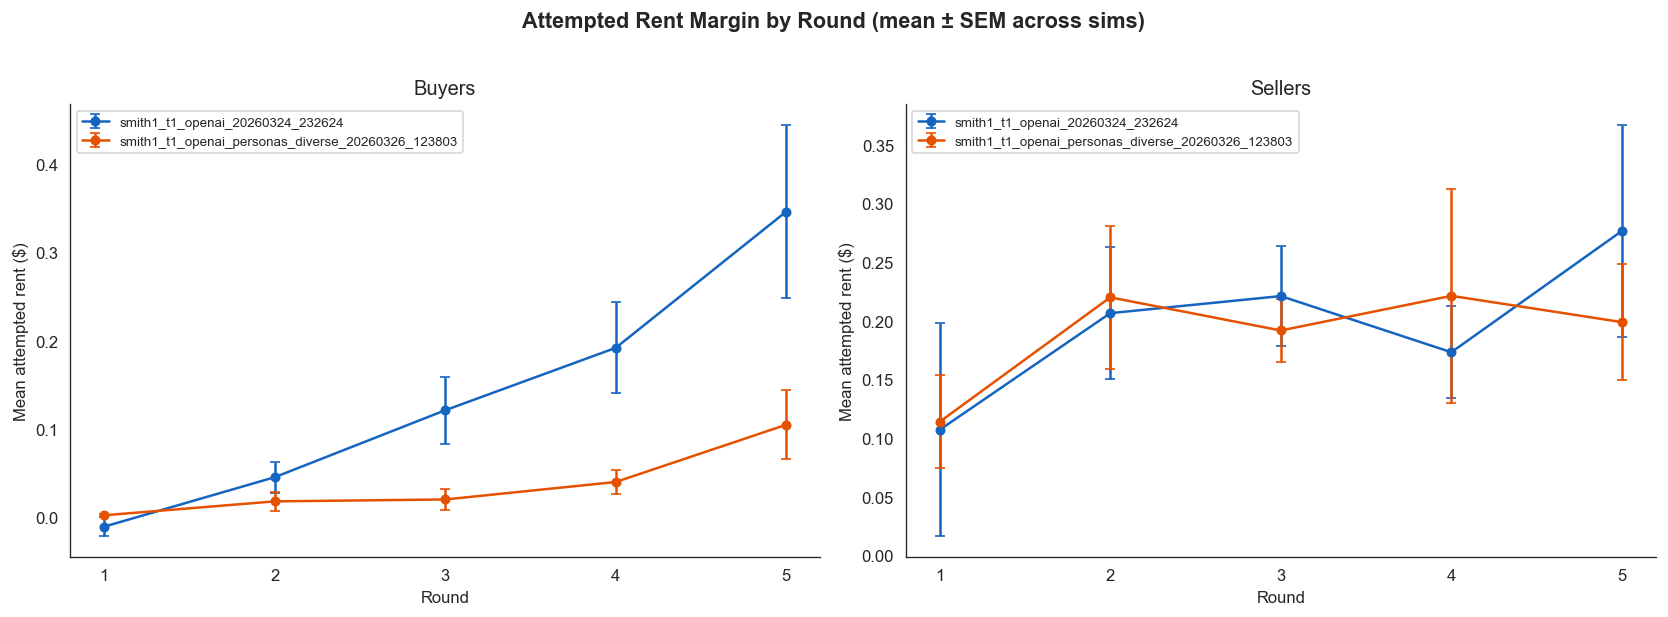

In [303]:
# ============================================================
# Comparison: Attempted Rent Margin by round
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, side in enumerate(['buyer', 'seller']):
    ax = axes[idx]
    for eid in experiment_ids:
        ann = experiments[eid]['ann']
        color = exp_colors[eid]
        sr = (ann[ann['side'] == side]
              .groupby(['sim', 'round'])['attempted_rent']
              .mean().reset_index())
        agg = sr.groupby('round')['attempted_rent'].agg(['mean', 'sem'])
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean attempted rent ($)')
    ax.set_title(f'{side.title()}s')
    ax.set_xticks(sorted(ann['round'].unique()))
    ax.legend(fontsize=8)

fig.suptitle('Attempted Rent Margin by Round (mean ± SEM across sims)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

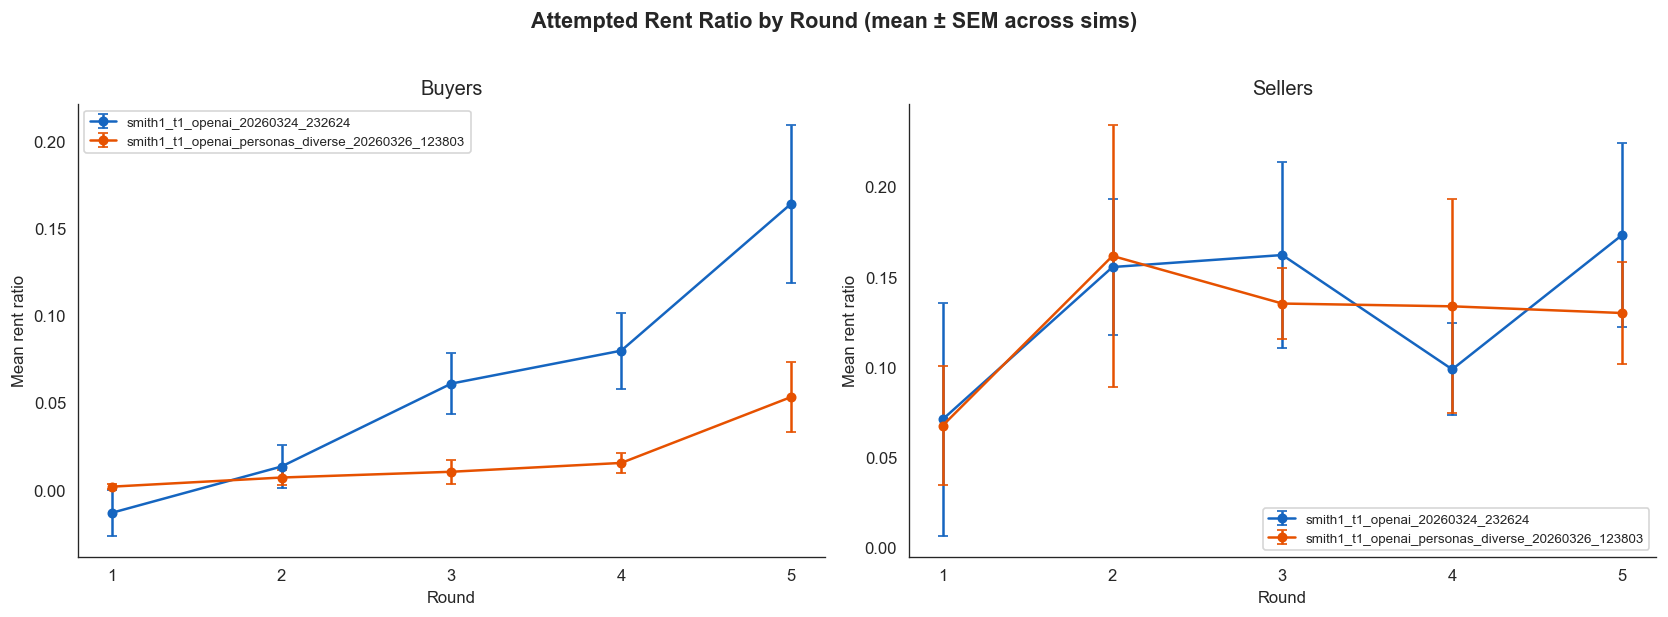

In [304]:
# ============================================================
# Comparison: Attempted Rent Ratio by round
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, side in enumerate(['buyer', 'seller']):
    ax = axes[idx]
    for eid in experiment_ids:
        ann = experiments[eid]['ann']
        color = exp_colors[eid]
        sr = (ann[ann['side'] == side]
              .groupby(['sim', 'round'])['rent_ratio']
              .mean().reset_index())
        agg = sr.groupby('round')['rent_ratio'].agg(['mean', 'sem'])
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean rent ratio')
    ax.set_title(f'{side.title()}s')
    ax.set_xticks(sorted(ann['round'].unique()))
    ax.legend(fontsize=8)

fig.suptitle('Attempted Rent Ratio by Round (mean ± SEM across sims)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

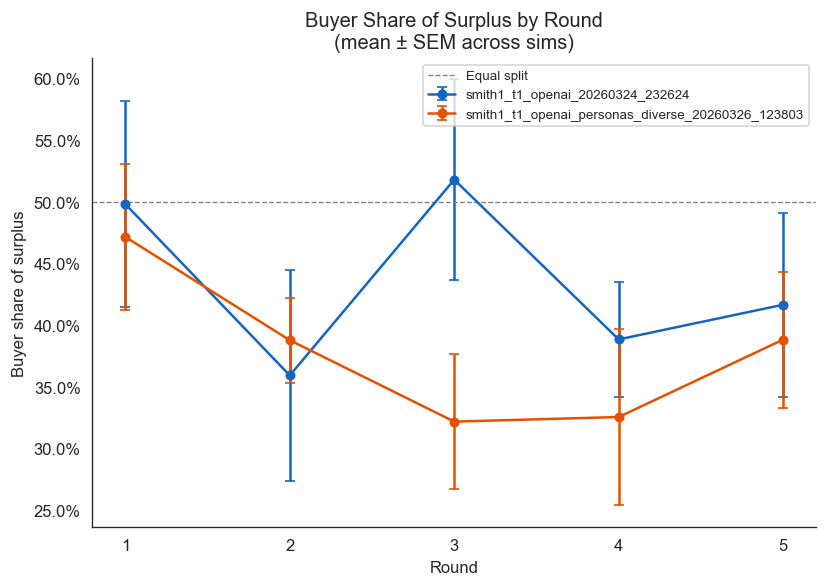

In [305]:
# ============================================================
# Comparison: Buyer share of surplus by round
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

for eid in experiment_ids:
    tx = experiments[eid]['tx']
    color = exp_colors[eid]
    tx_valid = tx.dropna(subset=['buyer_share'])
    sr = tx_valid.groupby(['sim', 'round'])['buyer_share'].mean().reset_index()
    agg = sr.groupby('round')['buyer_share'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)

ax.axhline(0.5, color='grey', ls='--', lw=0.8, label='Equal split')
ax.set_xlabel('Round')
ax.set_ylabel('Buyer share of surplus')
ax.set_title('Buyer Share of Surplus by Round\n(mean ± SEM across sims)')
ax.set_xticks(sorted(tx['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

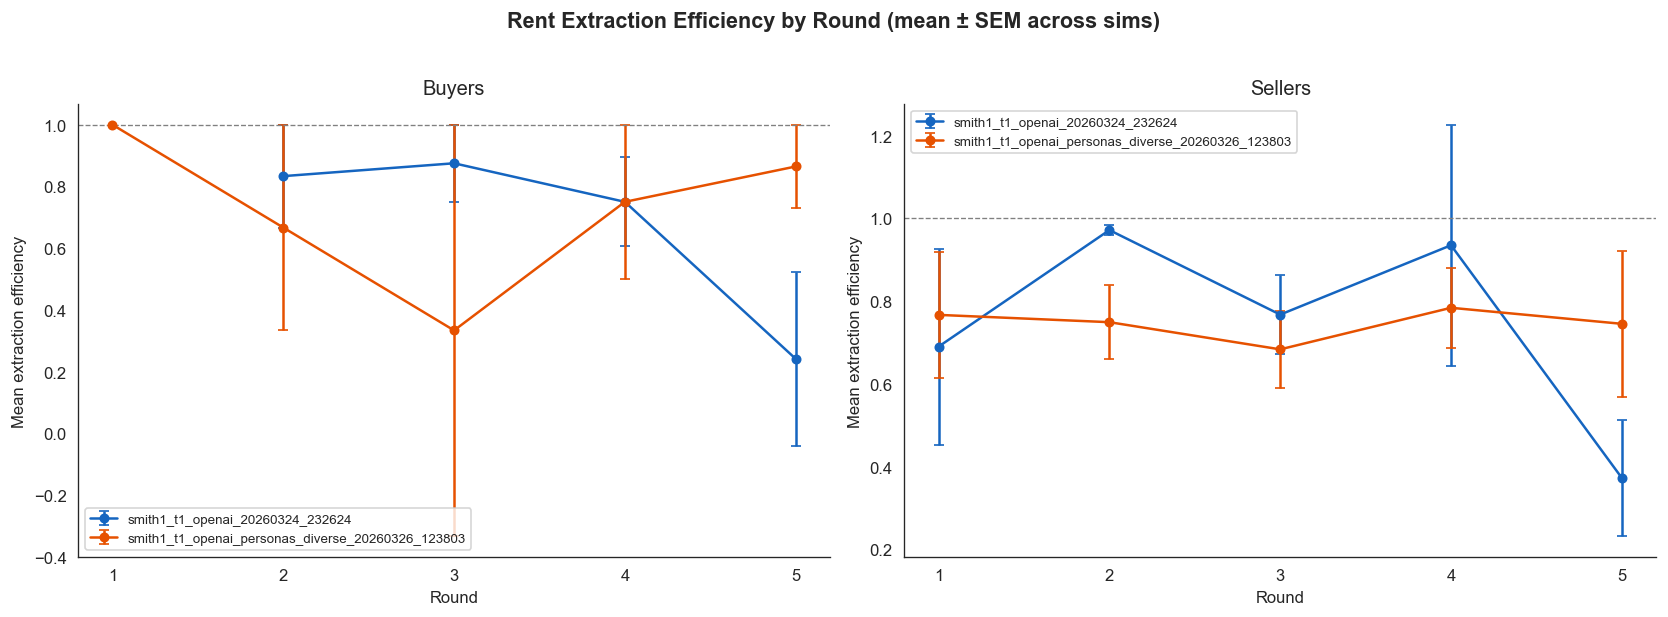

In [306]:
# ============================================================
# Comparison: Rent Extraction Efficiency by round
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, side in enumerate(['buyer', 'seller']):
    ax = axes[idx]
    for eid in experiment_ids:
        eff = experiments[eid]['eff']
        color = exp_colors[eid]
        sr = (eff[eff['side'] == side]
              .groupby(['sim', 'round'])['efficiency']
              .mean().reset_index())
        agg = sr.groupby('round')['efficiency'].agg(['mean', 'sem'])
        if len(agg) > 0:
            ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                        fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)
    ax.axhline(1.0, color='grey', ls='--', lw=0.8)
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean extraction efficiency')
    ax.set_title(f'{side.title()}s')
    ax.set_xticks(sorted(eff['round'].unique()))
    ax.legend(fontsize=8)

fig.suptitle('Rent Extraction Efficiency by Round (mean ± SEM across sims)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

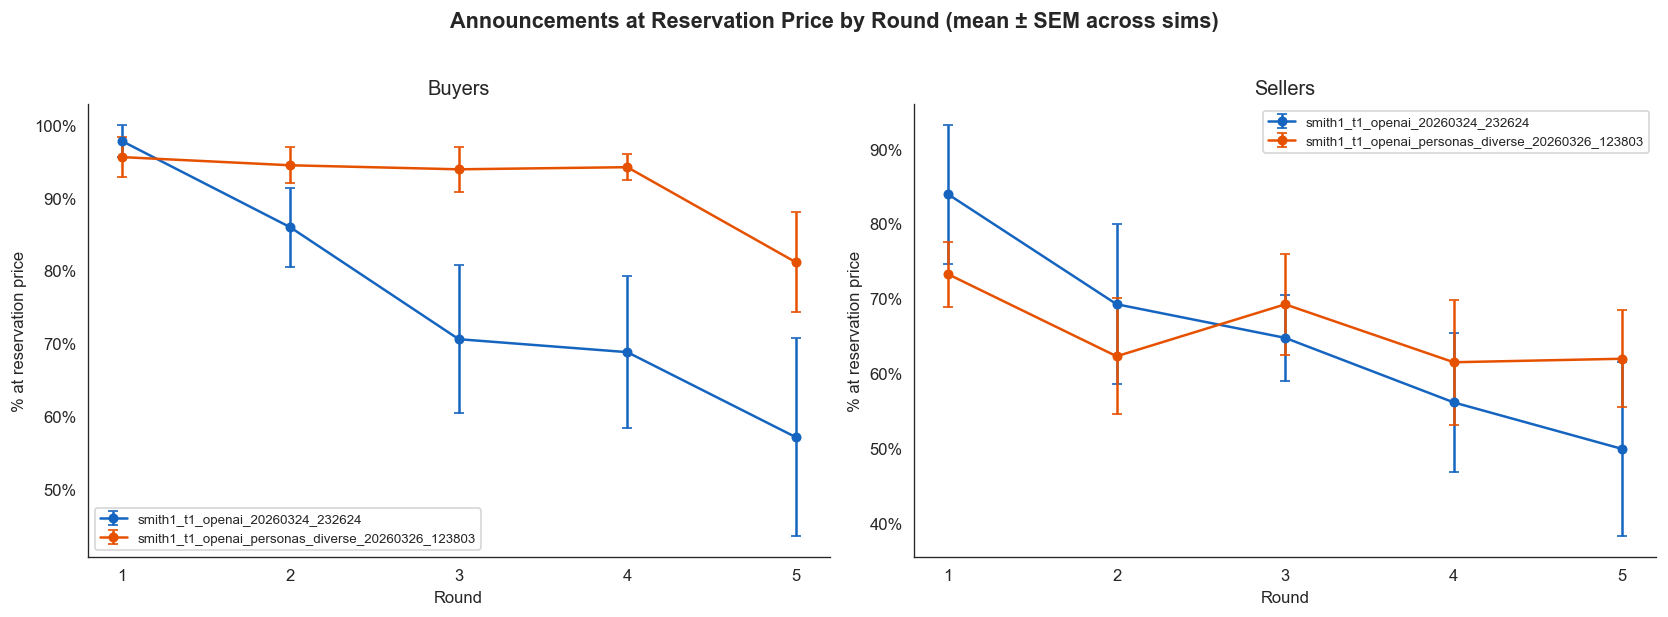

In [307]:
# ============================================================
# Comparison: % Announcements at Reservation Price by round
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, side in enumerate(['buyer', 'seller']):
    ax = axes[idx]
    for eid in experiment_ids:
        ann = experiments[eid]['ann']
        color = exp_colors[eid]
        sr = (ann[ann['side'] == side]
              .groupby(['sim', 'round'])
              .apply(lambda g: (g['attempted_rent'] == 0).mean())
              .reset_index(name='pct_at_res'))
        agg = sr.groupby('round')['pct_at_res'].agg(['mean', 'sem'])
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)
    ax.set_xlabel('Round')
    ax.set_ylabel('% at reservation price')
    ax.set_title(f'{side.title()}s')
    ax.set_xticks(sorted(ann['round'].unique()))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)

fig.suptitle('Announcements at Reservation Price by Round (mean ± SEM across sims)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

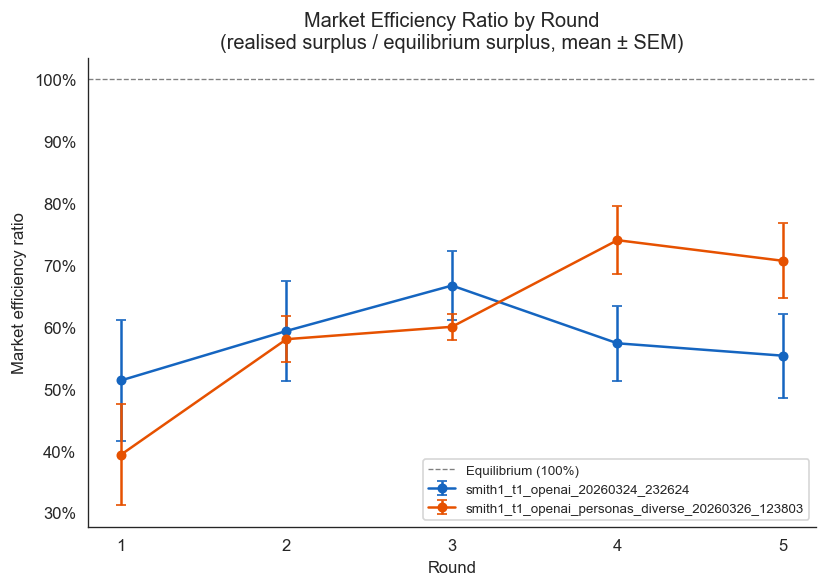

In [308]:
# ============================================================
# Comparison: Market Efficiency Ratio (realised / equilibrium surplus)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

for eid in experiment_ids:
    tx = experiments[eid]['tx']
    eq_surplus = experiments[eid]['total_eq_surplus']
    color = exp_colors[eid]
    sr = (tx.groupby(['sim', 'round'])['total_surplus']
          .sum().reset_index())
    sr['efficiency_ratio'] = sr['total_surplus'] / eq_surplus
    agg = sr.groupby('round')['efficiency_ratio'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)

ax.axhline(1.0, color='grey', ls='--', lw=0.8, label='Equilibrium (100%)')
ax.set_xlabel('Round')
ax.set_ylabel('Market efficiency ratio')
ax.set_title('Market Efficiency Ratio by Round\n(realised surplus / equilibrium surplus, mean ± SEM)')
ax.set_xticks(sorted(tx['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

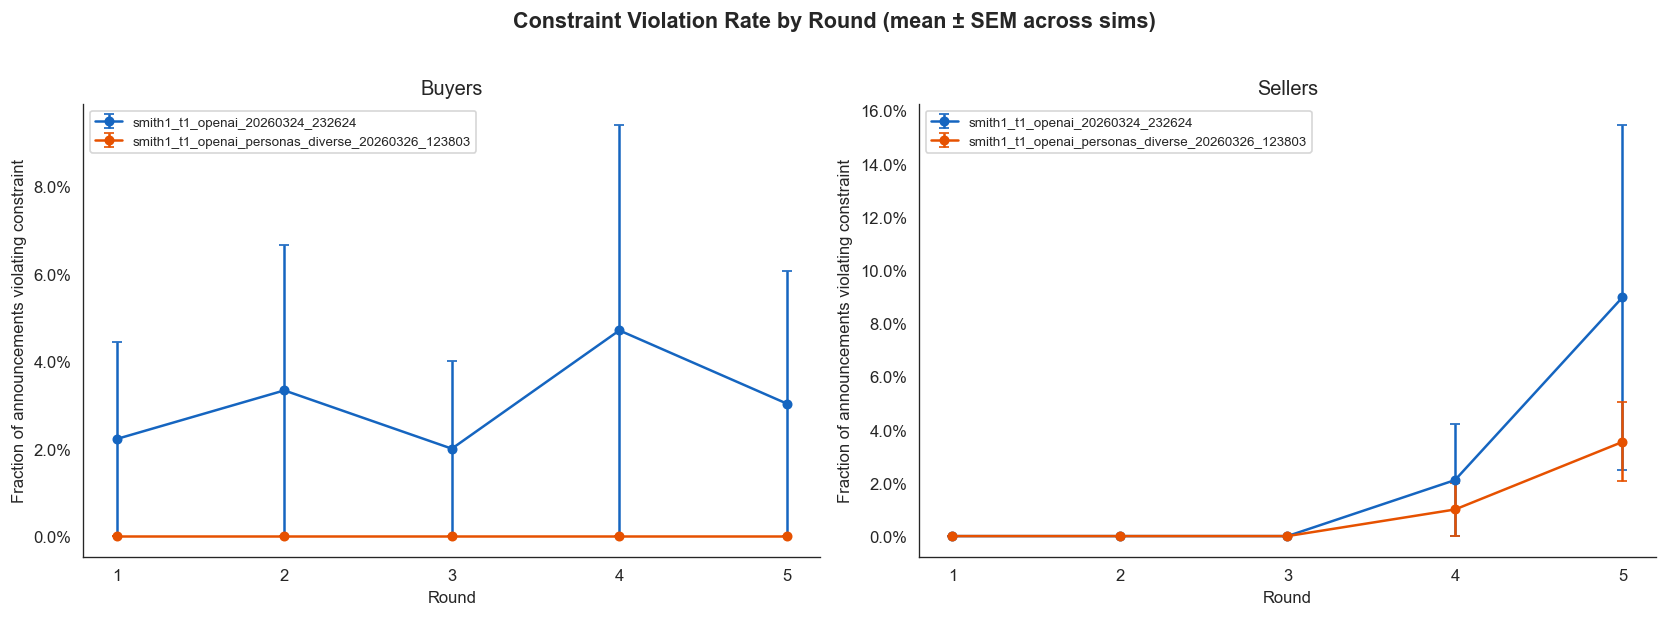

In [309]:
# ============================================================
# Comparison: Constraint Violation Rate by round
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, side in enumerate(['buyer', 'seller']):
    ax = axes[idx]
    for eid in experiment_ids:
        ann = experiments[eid]['ann']
        color = exp_colors[eid]
        ann_side = ann[ann['side'] == side].copy()
        ann_side['violation'] = ann_side['attempted_rent'] < 0
        sr = (ann_side.groupby(['sim', 'round'])['violation']
              .mean().reset_index())
        agg = sr.groupby('round')['violation'].agg(['mean', 'sem'])
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt='-o', color=color, capsize=3, label=exp_labels[eid], markersize=5)
    ax.set_xlabel('Round')
    ax.set_ylabel('Fraction of announcements violating constraint')
    ax.set_title(f'{side.title()}s')
    ax.set_xticks(sorted(ann['round'].unique()))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)

fig.suptitle('Constraint Violation Rate by Round (mean ± SEM across sims)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()